In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

In [103]:
DATA_DIR = "archive"
def load_pickle_file(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    return data

train_data = load_pickle_file(DATA_DIR + "/train")
test_data = load_pickle_file(DATA_DIR + "/test")
meta_data = load_pickle_file(DATA_DIR + "/meta")

/tmp/ipykernel_69102/1791542526.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


In [104]:
train_images = train_data["data"]
test_images = test_data["data"]

train_labels = np.array(train_data["fine_labels"])
test_labels = np.array(test_data["fine_labels"])

In [105]:
train_images = train_images.reshape(-1, 3, 32, 32)
test_images = test_images.reshape(-1, 3, 32, 32)
train_images = train_images.transpose(0, 2, 3, 1)
test_images = test_images.transpose(0, 2, 3, 1)
print("Quantidade de imagens, 32 de altura, 32 de largura, e 3 cores")
print(train_images.shape)
print(test_images.shape)
print("------")
print("Quantidade de labels disponíveis pra validar as imagens de treinamento e de teste: ")
print(train_labels.shape)
print(test_labels.shape)

Quantidade de imagens, 32 de altura, 32 de largura, e 3 cores
(50000, 32, 32, 3)
(10000, 32, 32, 3)
------
Quantidade de labels disponíveis pra validar as imagens de treinamento e de teste: 
(50000,)
(10000,)


Tanto o cifar 10 quanto o cifar 100 tem imagens 32 x 32 x 3,ou seja:
32 pixels de altura, 32 pixels de largura e .
3 canais de cor (RGB).

Carregamos os dados no separados em 4 subdatasets:

- `train_images` serão as imagens usadas para treinar o modelo.
- `train_labels` são as respostas corretas de `train_images`.
- `test_images` serão usadas para testar o modelo.
- `test_labels` são as respostas corretas de `test_images`.



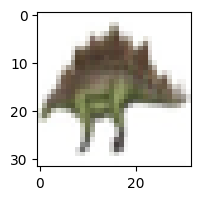

In [106]:
plt.figure(figsize=(2,2))
plt.imshow(train_images[1]);

Para verificar o conteúdo dos arquivos e formato dos dados:

In [107]:
print("Chaves de train_data:", train_data.keys())
print("Chaves de test_data:", test_data.keys())
print("Chaves de meta_data:", meta_data.keys())

Chaves de train_data: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])
Chaves de test_data: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])
Chaves de meta_data: dict_keys(['fine_label_names', 'coarse_label_names'])


O arquivo `meta` guarda os nomes das classes do cifar 100, temos 100 classes específicas.

In [108]:
class_names = meta_data['fine_label_names']
print("Número de classes:", len(class_names))
print("Primeiras 30 classes:", class_names[:30])


Número de classes: 100
Primeiras 30 classes: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur']


Normalização dos dados
Assim como no cifar 10, vamos fazer a normalização dos dados, dividindo todos os pixels por 255, deixando os valores entre 0 e 1.


In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Valor mínimo em train_images:", train_images.min())
print("Valor máximo em train_images:", train_images.max())

Vamos criar os conjuntos de imagens de validacao para esse modelo. Vamos separar 5000 imagens do conjunto de treino para validacao. Com isso, ficamos com: 
- 45000 imagens para treino.
- 5000 imagens para validaćao
- 10000 imagens para teste

In [ ]:
val_images = train_images[:5000]
val_labels = train_labels[:5000]

train_images = train_images[5000:]
train_labels = train_labels[5000:]

print("Train images:", train_images.shape)
print("Train labels:", train_labels.shape)
print("Validation images:", val_images.shape)
print("Validation labels:", val_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Train images: (45000, 32, 32, 3)
Train labels: (45000,)
Validation images: (5000, 32, 32, 3)
Validation labels: (5000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


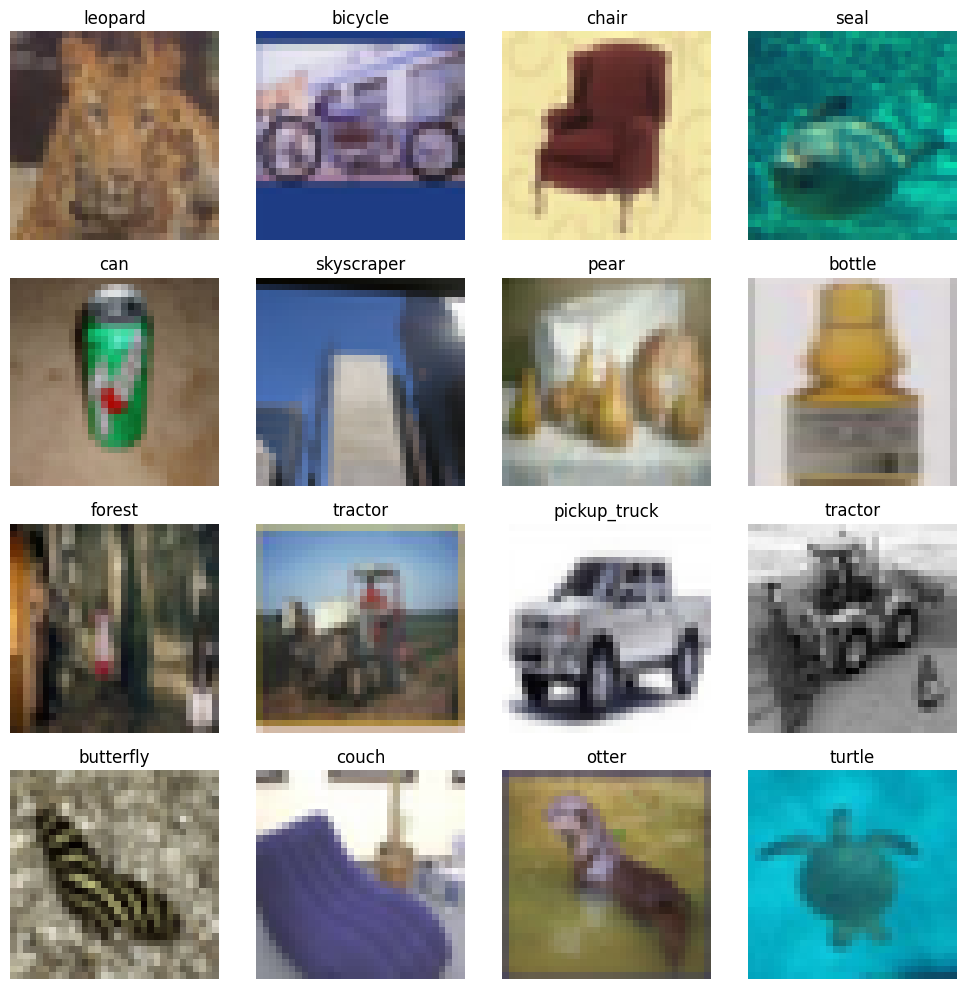

In [ ]:
# Para vermos algumas imagens
plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Criando a CNN

Teremos uma arquitetura similar ao notebook do cifar 10. A camada de convolućao terá 32 filtros, utilizaremos max pooling para reduzir o tamanho da imagem, e teremos uma camada convolucional com 64 filtros.

A primeira convolućao serve para detectar padroes simples, e a segunda detecta padroes mais complexos.

Depois das convolucoes e poolings, os dados ainda estariam no formato de imagem ou mapa de caracteristicas. Utilizaremos `flatten` para transformar a imagem num vetor unico, para ser utilizado na próxima camada. Esta será a camada densam com 64 neuronios, que irá decidir a classe da imagem. 

A camada final será a saída do modelo, e terá 100 neuronios por conta das 100 classes. Ela utilizará softmax, que transforma as saídas em probalilidades. Aqui, no cifar 10, eram 10 classes. 


In [ ]:
model = Sequential()
# primeira camada convolucional
model.add(Conv2D(
    input_shape=(32, 32, 3),
    filters=32,
    kernel_size=(3, 3),
    activation='relu'
))

# max pooling
model.add(MaxPool2D(2, 2))

# segunda camada convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))

# Segundo max pooling.
model.add(MaxPool2D())

# Flatten
model.add(Flatten())

# Camada de 64 neuronios
model.add(Dense(64, activation='relu'))

# camada final
model.add(Dense(100, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,148 (461.52 KB)

 Trainable params: 118,148 (461.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Antes de treinar, precisamos compilar o modelo. 
# O parametro "loss" é a funcao de perda para classificacao multiclasse
# O otimizador "adam" é o algoritmo que atualiza os pesos da rede durante o treinamento
# A acurácia mede a porcentagem de acertos.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Para treinar o modelo, precisamos especificar o numero de epocas. Uma época significa passar pelo conjunto de treino uma vez. Com 20 épocas, o modelo ve os dados de treino 20 vezes, por exemplo.

In [ ]:
NUM_EPOCHS = 20

history = model.fit(
    train_images,
    train_labels,
    epochs=NUM_EPOCHS,
    validation_data=(val_images, val_labels)
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1086 - loss: 3.8928 - val_accuracy: 0.1734 - val_loss: 3.5093
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.2179 - loss: 3.2522 - val_accuracy: 0.2390 - val_loss: 3.1286
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.2739 - loss: 2.9419 - val_accuracy: 0.2712 - val_loss: 3.0206
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3123 - loss: 2.7480 - val_accuracy: 0.2934 - val_loss: 2.8420
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3425 - loss: 2.6013 - val_accuracy: 0.3070 - val_loss: 2.7771
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3605 - loss: 2.4994 - val_accuracy: 0.3186 - val_loss: 2.7294
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3811 - loss: 2.4041 - val_accuracy: 0.3202 - val_loss: 2.7448
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3978 - loss: 2

Para analisarmos a acurácia:

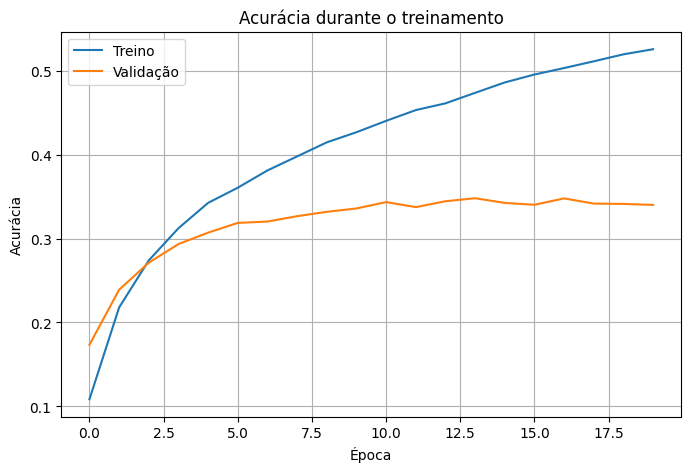

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia durante o treinamento')
plt.legend()
plt.grid(True)
plt.show()

Podemos plotar um gráfico da funćao de perda (loss).


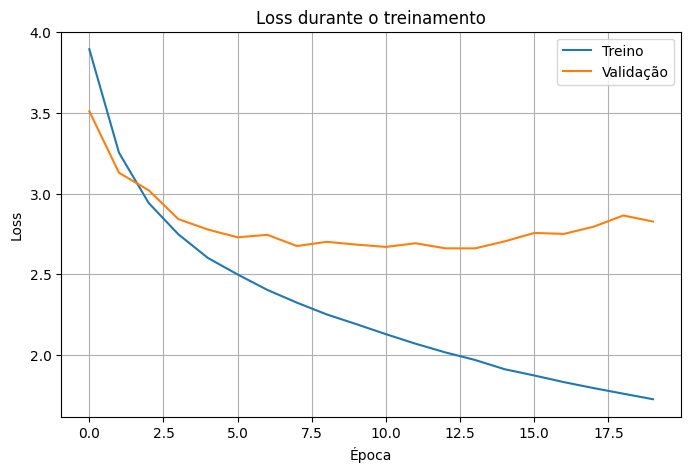

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss durante o treinamento')
plt.legend()
plt.grid(True)
plt.show()

A perda diminuiu duranre o treinamento, o que é positivo.

Para avaliar o modelo, analisaremos nos tres conjuntos: treino, validaćao, e teste.


In [ ]:
print("Avaliação no treino:")
model.evaluate(train_images, train_labels)

print("\nAvaliação na validação:")
model.evaluate(val_images, val_labels)

print("\nAvaliação no teste:")
model.evaluate(test_images, test_labels)

Avaliação no treino:
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5665 - loss: 1.5751

Avaliação na validação:
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3400 - loss: 2.8270

Avaliação no teste:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3475 - loss: 2.7631


[2.763052463531494, 0.3474999964237213]

A saída do modelo para cada imagem tem 100 valores, um para cada classe. Usamos np.argmax para pegar o indice de maior probabilidade. Esse indice representa a classe que foi prevista pelo modelo para aquela imagem.

In [ ]:
predictions = np.argmax(model.predict(test_images), axis=-1)

print("Formato de predictions:", predictions.shape)
print("Primeiras 10 predições:", predictions[:10])
print("Primeiros 10 labels reais:", test_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Formato de predictions: (10000,)
Primeiras 10 predições: [69 80 15 51 71 80 97 74 71 83]
Primeiros 10 labels reais: [49 33 72 51 71 92 15 14 23  0]


`classification_report` mostra métricas por classe como :

- **precision**: entre as imagens previstas como uma classe, quantas estavam corretas;
- **recall**: entre as imagens reais daquela classe, quantas o modelo encontrou;
- **f1-score**: média harmônica entre precision e recall;
- **support**: quantidade de exemplos daquela classe.

Como o CIFAR-100 tem 100 classes, o relatório será grande.

A matriz de confusao mostra onde o modelo erra e acerta. No cifar 100, ela tinha tamanho 10x10. Agora no Cifar100, ela tem tamanho 100x100.

In [ ]:
print(classification_report(
    test_labels,
    predictions,
    target_names=class_names
))

               precision    recall  f1-score   support

        apple       0.49      0.75      0.59       100
aquarium_fish       0.38      0.33      0.35       100
         baby       0.19      0.26      0.22       100
         bear       0.11      0.24      0.15       100
       beaver       0.30      0.30      0.30       100
          bed       0.27      0.27      0.27       100
          bee       0.40      0.33      0.36       100
       beetle       0.29      0.39      0.33       100
      bicycle       0.48      0.40      0.44       100
       bottle       0.60      0.49      0.54       100
         bowl       0.22      0.14      0.17       100
          boy       0.24      0.12      0.16       100
       bridge       0.32      0.36      0.34       100
          bus       0.29      0.32      0.30       100
    butterfly       0.26      0.29      0.27       100
        camel       0.24      0.35      0.29       100
          can       0.43      0.29      0.35       100
       ca

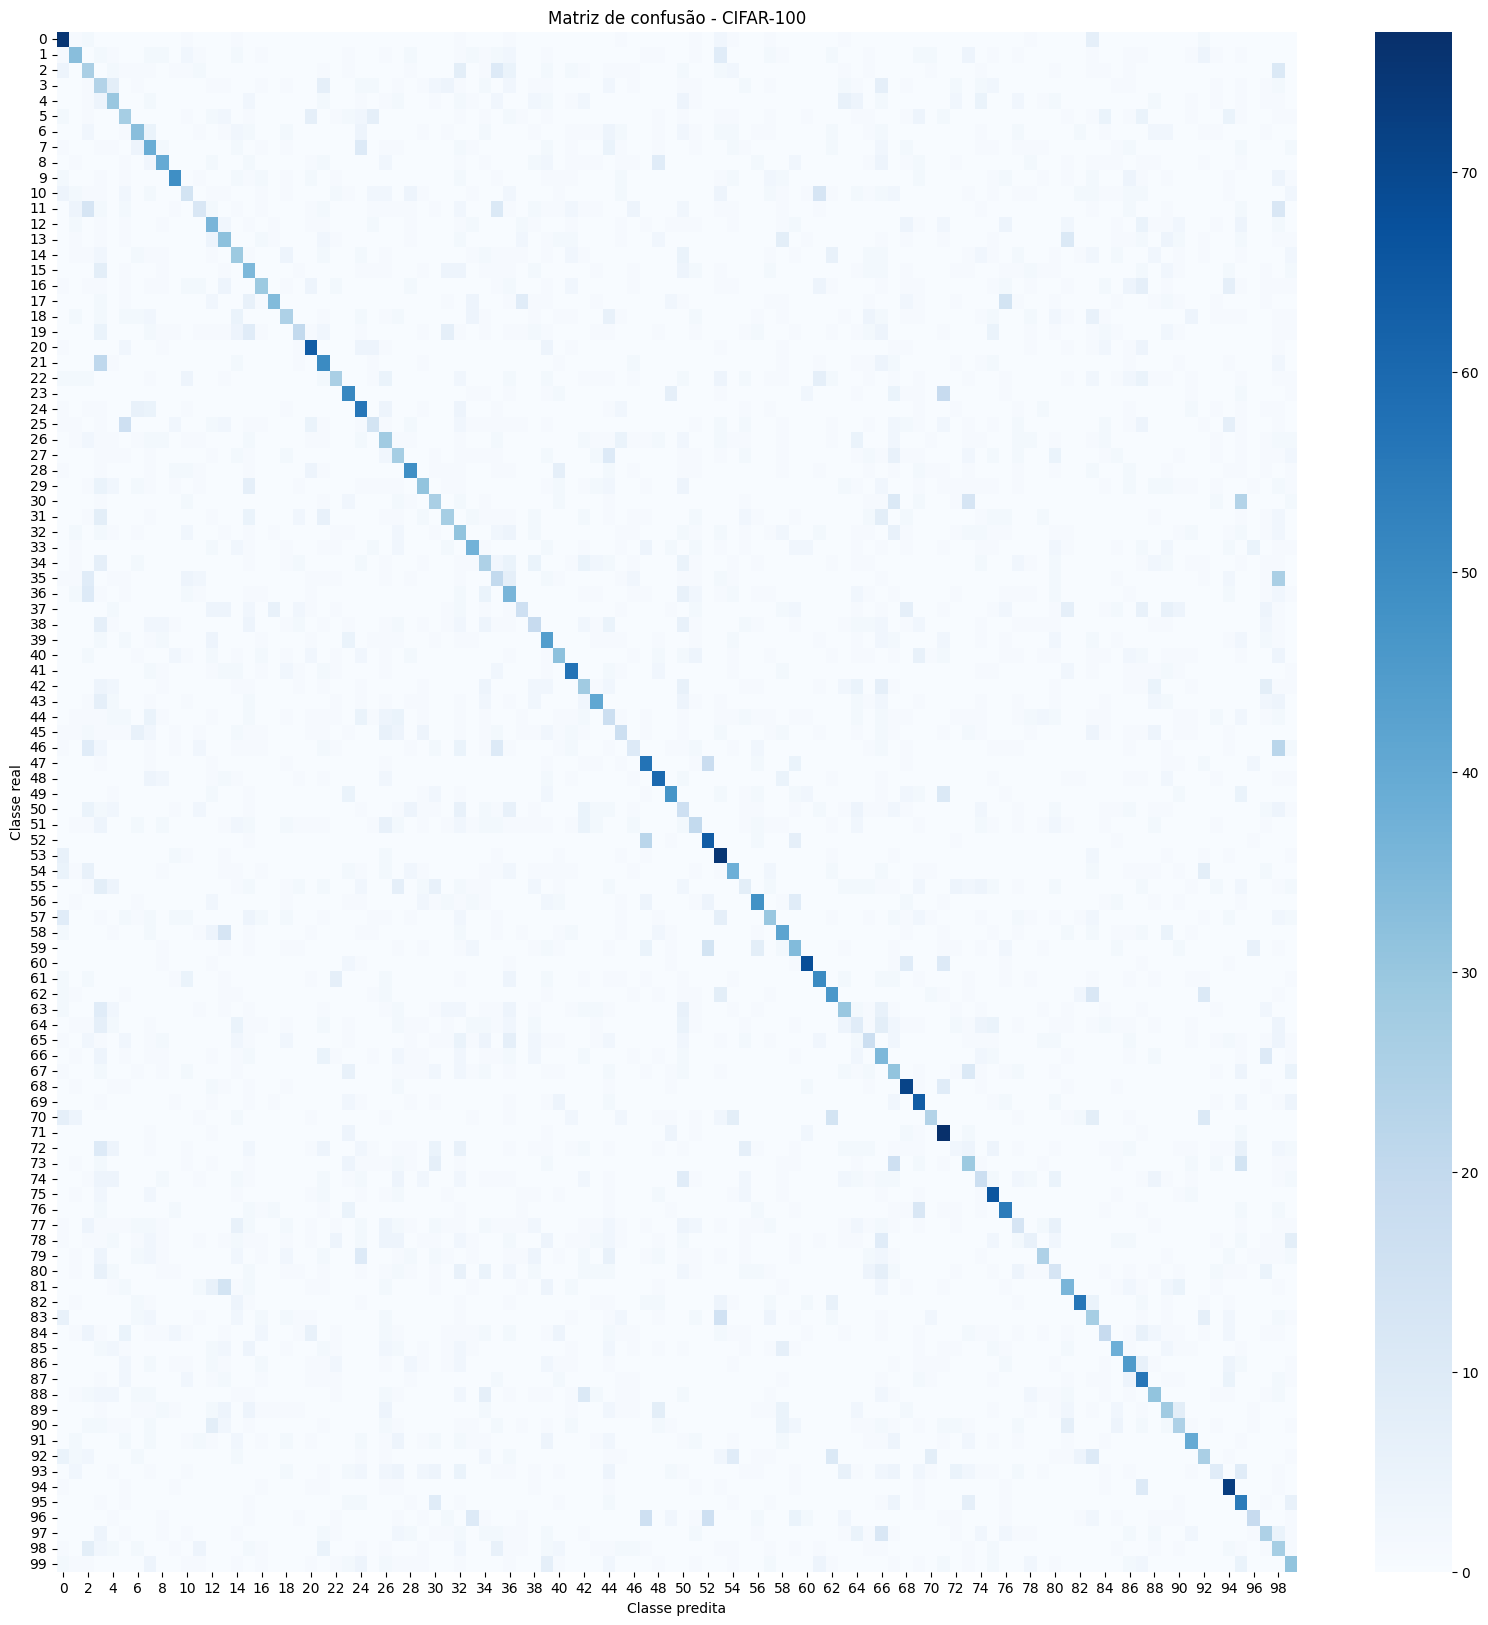

In [ ]:
# matriz de confusao
cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, cmap='Blues')
plt.xlabel('Classe predita')
plt.ylabel('Classe real')
plt.title('Matriz de confusão - CIFAR-100')
plt.show()

In [ ]:
# funcao para testar uma imagem especifica:
def img_pred(img_index, size=4):

    label = test_labels[img_index]
    my_image = test_images[img_index]

    plt.figure(figsize=(size, size))
    plt.imshow(my_image)

    # O modelo espera um lote de imagens.
    # Uma imagem sozinha tem formato (32, 32, 3)
    # Precisamos transformar para (1, 32, 32, 3)
    my_image_batch = my_image.reshape(1, 32, 32, 3)

    predicted_index = np.argmax(model.predict(my_image_batch))

    real_label = class_names[label]
    predicted_label = class_names[predicted_index]

    print(f"Label real: {real_label} . Predição: {predicted_label}")

    plt.grid(False)
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Label real: lamp . Predição: lamp


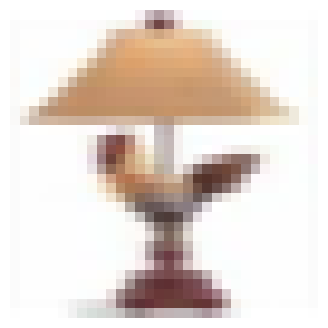

In [ ]:
img_pred(14)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Label real: bicycle . Predição: crab


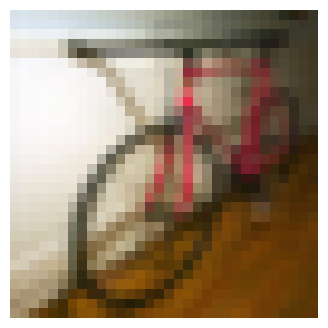

In [ ]:
img_pred(28)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Label real: bee . Predição: bee


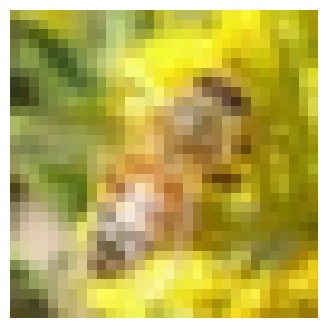

In [ ]:
img_pred(200)

Depois de treinar, podemos salvar o modelo.

Isso evita precisar treinar novamente toda vez que quisermos usar a rede.

O arquivo `.h5` contém a arquitetura e os pesos treinados.


In [ ]:
model.save('cifar_100_model.h5')

print("Modelo salvo como cifar_100_model.h5")